### Informe Final Carrera
#### Profundiza y ajusta la resolución de tus proyectos. Agrega una fuente de datos, prueba un modelo nuevo o responde una pregunta nueva. Elabora un informe final que describa el proceso de toma de decisiones. Sustenta la razón por la cual usaste las librerías y aplicaste los métodos al dataset. Todos tus hallazgos deberán ser comunicados en función de la problemática y las preguntas que buscabas responder.

#### Voy a partir del proyecto 3 en el cual realicé un sistema de recomendación basado en filtro colaborativo, en este caso, mi objetivo es crear un sistema de recomendación pero basado en contenido, de forma de usar información de cada usuario para recomendar nuevos ítems. Es decir voy a usar información del dataset que en el proyecto 3 no utilicé, como la columna 'genre' que nos da información sobre el género de cada juego. Teniendo esta información podremos recomendarle al usuario otros juegos de género similar.  
#### A diferencia del proyecto 3 en el cual usaba similitudes entre distintos usuarios para hacer las recomendaciones en este caso usaré el historial de cada usuario para recomendarle juegos. 

#### Importo las librerias que voy a usar

In [1]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set()

def parse(path):
    g = gzip.open(path, 'r')
    for l in g:
        yield eval(l)

#### Reviews

In [2]:
contador = 0
data_reviews = []
# Vamos a guardar una de cada 10 reviews para no llenar la memoria RAM. Si pones n = 3, 
# abrira uno de cada tres, y asi.
n = 10
for l in parse('steam_reviews.json.gz'):
    if contador%n == 0:
        data_reviews.append(l)
    else:
        pass
    contador += 1

In [3]:
data_reviews = pd.DataFrame(data_reviews)

In [4]:
data_reviews.head(100)

,username,hours,products,product_id,page_order,date,text,early_access,page,user_id,compensation,found_funny
0,Chaos Syren,0.1,41.0,725280,0,2017-12-17,This would not be acceptable as an entertainme...,False,1,NaN,NaN,NaN
1,Ariman1,13.2,1386.0,328100,2,2017-08-02,Addictive RPG ! Works fine on linux though it ...,False,1,NaN,NaN,NaN
2,freakfantom,0.1,1706.0,725280,5,2017-11-12,Прикольная стрелялка. Взял дешево на распродаже.,False,1,NaN,NaN,NaN
3,The_Cpt_FROGGY,7.8,2217.0,631920,0,2017-12-11,Somewhere on Zibylon:\n~~~~~~~~~~~~~~~~~~\nZib...,False,1,76561198003030375,Product received for free,NaN
4,the_maker988,8.2,18.0,35140,7,2018-01-02,"This game was way to linear for me, and compar...",False,1,76561198353396844,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,LemonHead,3.0,57.0,399660,3,2016-03-08,Similar to LoL but with military squads - lots...,False,4,NaN,NaN,NaN
96,MDS-95,0.5,625.0,302390,5,2014-07-12,"The game's a buggy mess, impossible to complet...",False,5,76561198035765383,NaN,NaN
97,novocain,3.8,1340.0,328100,2,2015-01-31,"Decent match-3 RPG, but it's a mobile port of ...",False,6,NaN,NaN,1.0
98,ISIS-Chan,3.7,89.0,434620,7,2017-08-21,This game is actually allot of fun I am pleasa...,False,1,NaN,NaN,NaN


#### Tamaño del dataset Reviews

In [5]:
data_reviews.shape

(779307, 12)

#### Valores faltantes en el dataset Reviews

In [6]:
data_reviews.isna().sum()

username             0
hours             2637
products          1566
product_id           0
page_order           0
date                 0
text                 0
early_access         0
page                 0
user_id         461967
compensation    764719
found_funny     659143
dtype: int64

#### Games

In [7]:
data_games = []
for l in parse('steam_games.json.gz'):
    data_games.append(l)
data_games = pd.DataFrame(data_games)

In [8]:
data_games.head()

,publisher,genres,app_name,title,url,release_date,tags,discount_price,reviews_url,specs,price,early_access,id,developer,sentiment,metascore
0,Kotoshiro,"[Action, Casual, Indie, Simulation, Strategy]",Lost Summoner Kitty,Lost Summoner Kitty,http://store.steampowered.com/app/761140/Lost_...,2018-01-04,"[Strategy, Action, Indie, Casual, Simulation]",4.49,http://steamcommunity.com/app/761140/reviews/?...,[Single-player],4.99,False,761140,Kotoshiro,NaN,NaN
1,"Making Fun, Inc.","[Free to Play, Indie, RPG, Strategy]",Ironbound,Ironbound,http://store.steampowered.com/app/643980/Ironb...,2018-01-04,"[Free to Play, Strategy, Indie, RPG, Card Game...",NaN,http://steamcommunity.com/app/643980/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free To Play,False,643980,Secret Level SRL,Mostly Positive,NaN
2,Poolians.com,"[Casual, Free to Play, Indie, Simulation, Sports]",Real Pool 3D - Poolians,Real Pool 3D - Poolians,http://store.steampowered.com/app/670290/Real_...,2017-07-24,"[Free to Play, Simulation, Sports, Casual, Ind...",NaN,http://steamcommunity.com/app/670290/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free to Play,False,670290,Poolians.com,Mostly Positive,NaN
3,彼岸领域,"[Action, Adventure, Casual]",弹炸人2222,弹炸人2222,http://store.steampowered.com/app/767400/2222/,2017-12-07,"[Action, Adventure, Casual]",0.83,http://steamcommunity.com/app/767400/reviews/?...,[Single-player],0.99,False,767400,彼岸领域,NaN,NaN
4,NaN,NaN,Log Challenge,NaN,http://store.steampowered.com/app/773570/Log_C...,NaN,"[Action, Indie, Casual, Sports]",1.79,http://steamcommunity.com/app/773570/reviews/?...,"[Single-player, Full controller support, HTC V...",2.99,False,773570,NaN,NaN,NaN


#### Tamaño del dataset Games

In [9]:
data_games.shape

(32135, 16)

#### Valores faltantes en el dataset Games

In [10]:
data_games.isna().sum()

publisher          8052
genres             3283
app_name              2
title              2050
url                   0
release_date       2067
tags                163
discount_price    31910
reviews_url           2
specs               670
price              1377
early_access          0
id                    2
developer          3299
sentiment          7182
metascore         29458
dtype: int64

#### Elimino aquellos juegos que no tengan información sobre el género

In [11]:
data_games.dropna(subset=['genres'], inplace = True)
data_games.isna().sum()

publisher          4897
genres                0
app_name              1
title                 1
url                   0
release_date         18
tags                 24
discount_price    28648
reviews_url           1
specs               286
price              1230
early_access          0
id                    1
developer           170
sentiment          6316
metascore         26239
dtype: int64

In [12]:
data_games['genres'].head(10)

0         [Action, Casual, Indie, Simulation, Strategy]
1                  [Free to Play, Indie, RPG, Strategy]
2     [Casual, Free to Play, Indie, Simulation, Sports]
3                           [Action, Adventure, Casual]
5                       [Action, Adventure, Simulation]
6             [Free to Play, Indie, Simulation, Sports]
7             [Free to Play, Indie, Simulation, Sports]
8             [Free to Play, Indie, Simulation, Sports]
9                   [Casual, Indie, Racing, Simulation]
10            [Action, Indie, Simulation, Early Access]
Name: genres, dtype: object

#### Géneros más populares

In [13]:
genre_popularity = (data_games['genres'].explode().value_counts()
                    .sort_values(ascending=False))

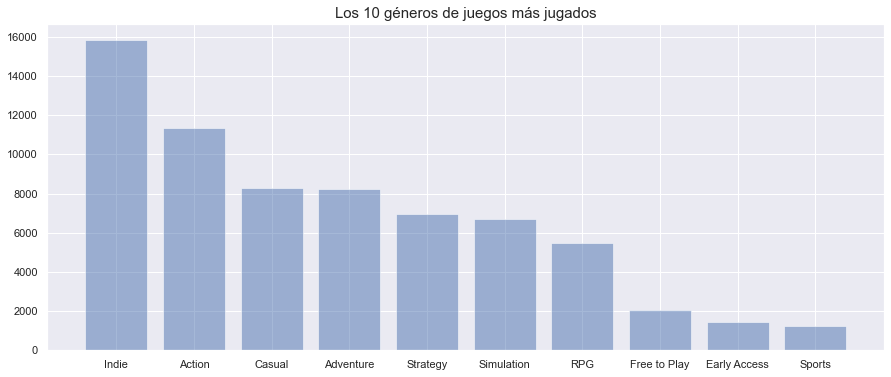

In [14]:
plt.figure(figsize = (15,6))
plt.bar(genre_popularity.index[:10], genre_popularity.head(10),align='center', alpha=0.5)
plt.title('Los 10 géneros de juegos más jugados', fontsize = 15)
plt.show()

#### Vemos que el género que predomina en los juegos del data set es 'Indie' y 'Action'

#### Otra forma de visualizar cuál es el género que más aparece entre los juegos del dataset es a través de un Word Cloud o 'Nube de Palabras', donde también se observa que  las palabras 'Indie', 'Action','Casual' y 'Adventure' son las más grandes, es decir las que más se repiten

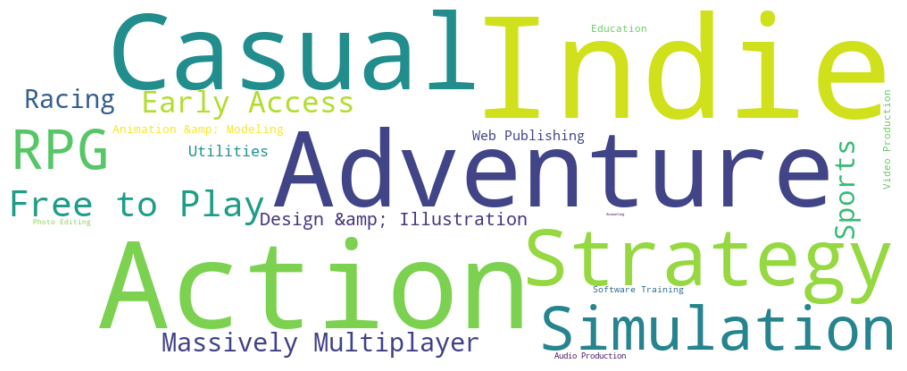

In [15]:
genre_wc = WordCloud(width=1000,height=400,background_color='white')
genre_wc.generate_from_frequencies(genre_popularity.to_dict())
plt.figure(figsize=(16, 8))
plt.imshow(genre_wc, interpolation="bilinear")
plt.axis('off')
plt.show()

#### Para crear el sistema de recomendación basado en contenido, necesitamos una forma de medir la similitud entre los distintos juegos, de forma de recomendarle a cada usuario juegos parecidos a los que ya jugó y le gustaron.  Una forma de poder medir esta similitud es contando el numero maximo de palabras comunes entre los documentos, en este caso entre los distintos juegos, pero hay un problema allí y es que si el tamaño del 'documento' es decir del texto en la columna 'genres' aumenta, también lo hará el número de veces que se repite la palabra, incluso si el texto habla de un tema diferente. 
#### Para evitar este problema, hay una métrica llamada 'la similitud del coseno', la cual se usa para determinar cuánto se parecen distintos documentos independientemente del tamaño de ellos. 
#### Para hacerlo, mide el coseno del ángulo entre dos vectores, en este caso, los vectores son arrays que contienen el conteo de palabras de cada documento, cuanto menor es el ángulo mayor la similitud.
#### Pero antes de poder calcular la similitud del coseno entre los géneros de los juegos tengo que convertir esta información en vectores, de forma de que luego se pueda calcular el coseno del ángulo que forman. Para este primer paso voy a usar la librería TF-IDF Vectorizer de scikit-learn.
#### TF-TDF es la abreviación de Term Frequency Inverse Document Frequency. Es un algoritmo capaz de transformar texto en una representación numérica característica, que puede usarse para entrenar un modelo de machine learning. 

#### Primero armo un Dataframe con los datos que voy a usar: 

In [67]:
data = data_games.copy()
data.drop(['publisher','app_name','url','release_date', 
            'tags','discount_price','reviews_url','specs','price',
            'early_access','developer','sentiment','metascore']
           , axis=1, inplace = True)
print(data.shape)
 
data.head()

(28852, 3)


,genres,title,id
0,"[Action, Casual, Indie, Simulation, Strategy]",Lost Summoner Kitty,761140
1,"[Free to Play, Indie, RPG, Strategy]",Ironbound,643980
2,"[Casual, Free to Play, Indie, Simulation, Sports]",Real Pool 3D - Poolians,670290
3,"[Action, Adventure, Casual]",弹炸人2222,767400
5,"[Action, Adventure, Simulation]",Battle Royale Trainer,772540


In [68]:
#Construyo un indice con los titulos de los juegos
indices = pd.Series(data.index, index=data['title'])

In [69]:
indices.head()

title
Lost Summoner Kitty        0
Ironbound                  1
Real Pool 3D - Poolians    2
弹炸人2222                    3
Battle Royale Trainer      5
dtype: int64

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [71]:
def dummy_fun(doc):
    return doc

tfidf = TfidfVectorizer(
    analyzer='word',
    tokenizer=dummy_fun,
    preprocessor=dummy_fun,
    token_pattern=None
)

In [72]:
tfidf_matrix = tfidf.fit_transform(data['genres'])

In [73]:
tfidf.get_feature_names()

['Accounting',
 'Action',
 'Adventure',
 'Animation &amp; Modeling',
 'Audio Production',
 'Casual',
 'Design &amp; Illustration',
 'Early Access',
 'Education',
 'Free to Play',
 'Indie',
 'Massively Multiplayer',
 'Photo Editing',
 'RPG',
 'Racing',
 'Simulation',
 'Software Training',
 'Sports',
 'Strategy',
 'Utilities',
 'Video Production',
 'Web Publishing']

#### Tamaño de la matriz: Cada fila corresponde a cada juego y las columnas corresponden a los diferentes géneros que aparecen en todas ellas. 
#### La matriz muestra de forma numérica los géneros que más representan a cada juego

In [74]:
tfidf_matrix.shape

(28852, 22)

In [75]:
matrix = pd.DataFrame(tfidf_matrix.todense(),columns = tfidf.get_feature_names(),index = data['title']).sample(21, axis=1).sample(100, axis=0)

In [76]:
matrix.head()

,Web Publishing,Audio Production,Simulation,Design &amp; Illustration,Sports,Early Access,Casual,Software Training,Utilities,Free to Play,...,Video Production,RPG,Action,Photo Editing,Adventure,Indie,Education,Racing,Massively Multiplayer,Animation &amp; Modeling
title,,,,,,,,,,,,,,,,,,,,,
Empathy: Path of Whispers - Original soundtrack,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.573841,0.0,0.667906,0.473928,0.0,0.0,0.0,0.0
Battlevoid: Harbinger,0.0,0.0,0.576327,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.453420,0.0,0.000000,0.374474,0.0,0.0,0.0,0.0
Achievement Hunter: Pharaoh,0.0,0.0,0.000000,0.0,0.0,0.0,0.554608,0.0,0.0,0.0,...,0.0,0.0,0.477500,0.0,0.555772,0.394361,0.0,0.0,0.0,0.0
Street Fighter X Tekken: Marduk (Swap Costume),0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
Dungeon Lords Steam Edition,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [77]:
matrix.iloc[0,:]

Web Publishing               0.000000
Audio Production             0.000000
Simulation                   0.000000
Design &amp; Illustration    0.000000
Sports                       0.000000
Early Access                 0.000000
Casual                       0.000000
Software Training            0.000000
Utilities                    0.000000
Free to Play                 0.000000
Accounting                   0.000000
Video Production             0.000000
RPG                          0.000000
Action                       0.573841
Photo Editing                0.000000
Adventure                    0.667906
Indie                        0.473928
Education                    0.000000
Racing                       0.000000
Massively Multiplayer        0.000000
Animation &amp; Modeling     0.000000
Name: Empathy: Path of Whispers - Original soundtrack, dtype: float64

In [78]:
data[data['title'] == 'OMSI 2 Add-On Citybus O405/O405G']

,genres,title,id
5555,[Simulation],OMSI 2 Add-On Citybus O405/O405G,434061


#### Como ejemplo, el juego titulado 'OMSI 2 Add-On Citybus O405/O405G', está categorizado como en la columna 'genres' como 'Simulation', y como se muestra en la matriz la columna 'Simulation' es la única que tiene un 1, y el resto de las columnas, que representan a los demás géneros tienen 0.

#### El siguiente paso es encontrar vectores tf-idf similares, es decir juegos similares. Esto lo haré utilizando la similaridad del coseno

In [79]:
from sklearn.metrics.pairwise import cosine_similarity

In [80]:
cosine_sim = cosine_similarity(tfidf_matrix)

#### Esta nueva matriz llamada cosine_sim tiene un tamaño igual al número de juegos x número de juegos, e indica para cada juego la métrica de similitud, es decir la 'distancia' a cada uno de los demás juegos del dataset. 

In [81]:
cosine_sim.shape

(28852, 28852)

In [82]:
cosine_sim[1]

array([0.32504352, 1.        , 0.44586188, ..., 0.42716516, 0.09165339,
       0.17245852])

#### Defino una función que reciba como parámetro el título de un juego y la matriz de similitud coseno y devuelva los N que más se le parecen 

In [83]:
def get_recommendations(title, N, cosine_sim = cosine_sim):
    
    #Primero obtengo el indice del juego que corresponde al titulo 
    index = indices[title]

    # Obtengo la métrica cosine_sim de todos los juegos con respecto al que ingresa en la funcion
    sim_scores = list(enumerate(cosine_sim[index]))

    # Ordeno los juegos de mayor a menor
    cosine_scores = sorted(sim_scores, key = lambda x: x[1], reverse = True)

    # Me quedo con los N juegos más parecidos
    sim_scores = sim_scores[1:N]

    # Get the movie indices
    games_index = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    print('Recommending ' + str(N) + ' products similar to ' + title)
    return data['title'].iloc[games_index]

In [84]:
get_recommendations('The Journey Down: Chapter Two',10)

Recommending 10 products similar to The Journey Down: Chapter Two


1                         Ironbound
2           Real Pool 3D - Poolians
3                           弹炸人2222
5             Battle Royale Trainer
6      SNOW - All Access Basic Pass
7        SNOW - All Access Pro Pass
8     SNOW - All Access Legend Pass
9                              Race
10                  Uncanny Islands
Name: title, dtype: object

#### Creé un sistema de recomendación basado en contenido, es decir un sistema que tienen en cuenta las caracteristicas del juego que me interesa para mostrarme otros juegos con caracteristicas similares

#### Traigo informacion del proyecto 3, el mejor modelo de filtro colaborativo que creé y la función que según el nombre de usuario recomienda N juegos

In [34]:
%store -r reviews

In [35]:
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import train_test_split
from surprise import SVDpp
from surprise import accuracy

In [36]:
reader = Reader()

In [66]:
data2 = Dataset.load_from_df(reviews[['username', 'product_id', 'rating_sent']], reader)
trainset, testset = train_test_split(data2, test_size=.25)

In [38]:
algo = SVDpp()
algo.fit(trainset) 
predictions_svdpp = algo.test(testset)

In [39]:
RMSE_svdpp = accuracy.rmse(predictions_svdpp)

RMSE: 0.1474


In [40]:
def recomendaciones(usuario, N):
    
    #Estos son los juegos que jugó
    usuario_jugados = reviews[reviews['username'] == usuario].copy()
        
    #Armo el dataframe que devolverá la función y elimino los juegos que el usuario ya jugó
    recomendaciones_usuario = reviews.drop(['username', 'rating_sent'], axis = 1).copy()
    recomendaciones_usuario['product_id'][~recomendaciones_usuario['product_id'].isin(usuario_jugados['product_id'])]
    recomendaciones_usuario.reset_index(drop = True, inplace = True)
    
    #Estimaciones del modelo
    recomendaciones_usuario['Estimate_Score'] = recomendaciones_usuario['product_id'].apply(lambda x: algo.predict(usuario, x).est)
    recomendaciones_usuario = recomendaciones_usuario.sort_values('Estimate_Score', ascending=False)
    recomendaciones_usuario.drop_duplicates(inplace = True)
    recomendaciones_usuario.reset_index(drop = True, inplace = True)
    
    return recomendaciones_usuario.head(N)

In [86]:
titulo = recomendaciones('The_Cpt_FROGGY', 1)['title'][0]

In [87]:
titulo

'Crysis Warhead®'

In [88]:
get_recommendations(titulo,10)

Recommending 10 products similar to Crysis Warhead®


1                         Ironbound
2           Real Pool 3D - Poolians
3                           弹炸人2222
5             Battle Royale Trainer
6      SNOW - All Access Basic Pass
7        SNOW - All Access Pro Pass
8     SNOW - All Access Legend Pass
9                              Race
10                  Uncanny Islands
Name: title, dtype: object

#### Armo una funcion que use las dos funciones

In [93]:
def recomendacion_usuario(usuario, N):
    Mejor_juego_usuario = recomendaciones(usuario, 1)

    print('Para el usuario ingresado: ' + str(usuario) + ' que estimamos que califica con ' 
          + str(int(Mejor_juego_usuario['Estimate_Score'])) + ' puntos al juego llamado ' + str(Mejor_juego_usuario['title'][0])
          + ' le recomendamos también los siguientes juegos :')  
    return get_recommendations(Mejor_juego_usuario['title'][0], N)
    

In [94]:
recomendacion_usuario('The_Cpt_FROGGY', 5)

Para el usuario ingresado: The_Cpt_FROGGY que estimamos que califica con 3 puntos al juego llamado Crysis Warhead® le recomendamos también los siguientes juegos :
Recommending 5 products similar to Crysis Warhead®


1                  Ironbound
2    Real Pool 3D - Poolians
3                    弹炸人2222
5      Battle Royale Trainer
Name: title, dtype: object

#### Tenemos una funcion que utiliza los dos tipos de sistemas de recomendación (colaborativo del proyecto 3 y el basado en contenido). Llamamos a la funcion recomendacion_usuario y le pasamos el nombre del usuario y la cantidad de juegos que queremos que recomiende, internamente la funcion utiliza el sistema de recomendacion de filtro colaborativo para encontrar el juego que predice como el que el usuario mejor puntuaría y le recomienda N similares a este. 